In [1]:
%matplotlib inline
# !pip install deeptrack deeplay # Uncomment if running in colab/kaggle

<!--<badge>--><a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx231G_LodeSTAR_track_plankton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

In [2]:
import deeptrack as dt
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
import torch

## 1. Define helper functions

In [3]:
def normalize_min_max(img, squeeze_in_2D=False):
    """Normalizes intensities."""
    if squeeze_in_2D:
        img = np.squeeze(img)
    max_intensity = np.max(img)
    min_intensity = np.min(img)
    if max_intensity == min_intensity:
        raise ValueError("Cannot normalize array with uniform intensity.")
    normalized_img = (img - min_intensity) / (
        max_intensity - min_intensity)
    return normalized_img

## 2. Load data

(150, 150)


(-0.5, 149.5, 149.5, -0.5)

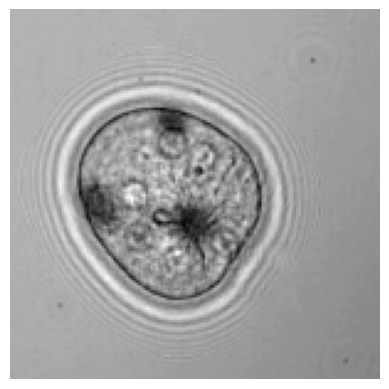

In [4]:
plankton_data = normalize_min_max(np.load("./assets/plankton.npy"))

t, x, y, w = (0, 450, 320, 150) 
crop = plankton_data[t, y:y+w, x:x+w, 0]
print(crop.shape)
plt.imshow(crop, cmap="gray")
plt.axis("off")

## 3. Train Model

c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:477: The total number of parameters detected may be inaccurate because the model contains an instanc

Training: |          | 0/? [00:00<?, ?it/s]

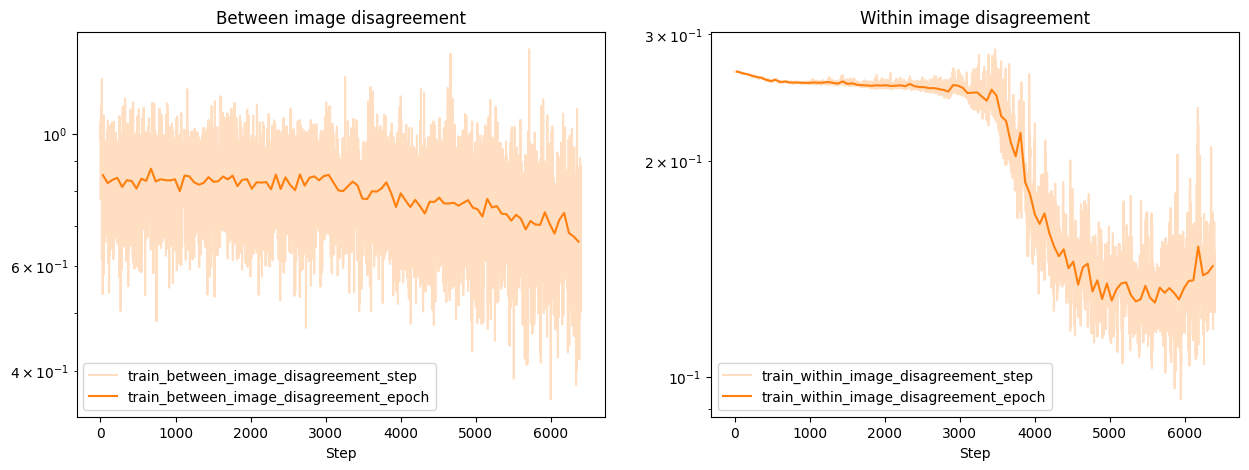

In [5]:
# Add empty batch dimension for compatability.
training_crop = crop[np.newaxis]
downsample = 5
model = dl.LodeSTAR(n_transforms=4, optimizer=dl.Adam(lr=1e-4)).build()

training_pipeline = (
    dt.Value(training_crop)
    >> dt.AveragePooling(ksize=(downsample, downsample, 3))
    >> dt.Affine(rotate=lambda: np.random.rand()*np.pi*2, scale=lambda:np.random.uniform(0.95, 1.05, 2))
    >> dt.Add(lambda: np.random.randn() * 0.2)
    >> dt.Gaussian(sigma=lambda:np.random.uniform(0, 0.01))  
    >> dt.Multiply(lambda: np.random.uniform(0.3, 1.6))
    
    >> dt.pytorch.ToTensor(dtype=torch.float32)
)

train_dataset = dt.pytorch.Dataset(
     training_pipeline,
     length=256,
     replace=False,
)
dataloader = dl.DataLoader(
     train_dataset,
     batch_size=4,
     shuffle=True,
)

# Start training.
trainer_lodestar = dl.Trainer(max_epochs=100, accelerator="auto")
trainer_lodestar.fit(model, dataloader)

# Plot history and save weights.
trainer_lodestar.history.plot()
torch.save(model.state_dict(), "lodestar_weights_plankton.pth")

## Test Model

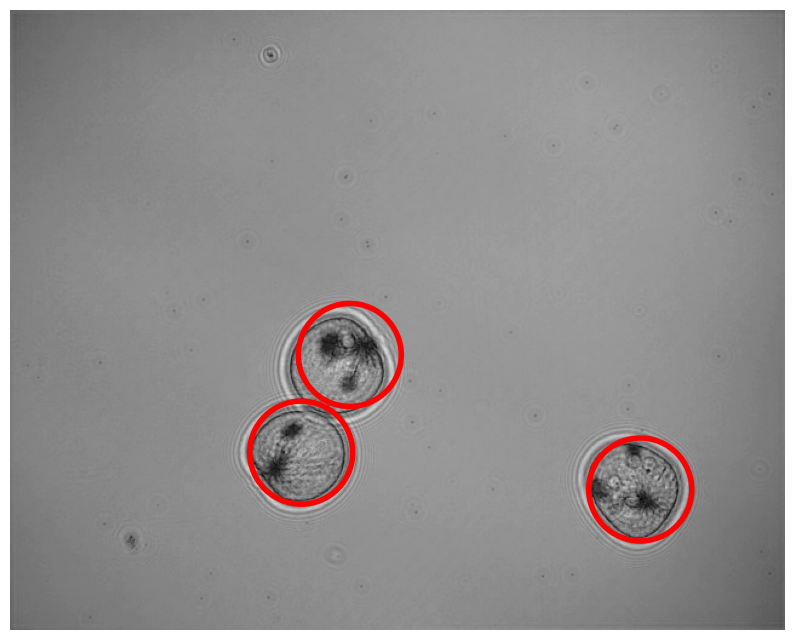

In [17]:
# May need to tune these to get optimal performance!
alpha = 0.95
cutoff = 0.8

# Last frame of the movie.
frame_index = 1
experimental_image = plankton_data[frame_index:frame_index+1,::downsample, ::downsample, 0]

# Convert to tensor for LodeSTAR.
image = torch.as_tensor(
    experimental_image,
    dtype=torch.float32
).detach().to("cpu").unsqueeze(0)

detections = model.detect(image, alpha=alpha, beta=1-alpha, cutoff=cutoff, mode="quantile")[0]
plt.figure(figsize=(10, 10))
plt.imshow(plankton_data[frame_index], cmap="gray")
plt.axis("off")
plt.scatter(detections[:, 1]*downsample, detections[:, 0]*downsample, s=5500, linewidths=4, facecolors="none", edgecolors="r")